In [1]:
import pandas as pd
import numpy as np
import os
# working dir
work_path = "C:/Users/wenlou/Documents/Python Scripts"
data_path = "P:/3026008.01/Data/"
pred_path = 'C:/Users/wenlou/Documents/MATLAB/Prediction'
os.chdir(work_path)
from help_function import *

#read subject list     
sub_id_lst = read_sub_lst()

#############################
m_id = 70
#sub_id_lst = sub_group_lst(m_id)
fontsize = 14

In [2]:
####################
## data preparation
####################

######  BEH 
df_beh = processBehDat()

# Data for fig A  - average confidence by sub
meanBehConfBySub = df_beh.groupby(['sub_id', 'delta_VA','ComSourLbl'])['confLvl'].agg(['mean', 'count']).reset_index()
meanBehConfBySub.columns = ['sub_id', 'delta_VA','ComSourLbl', 'avgConfLvl', 'count']

# Data for fig C  - percent of common for each disparity
cntBehBySub = df_beh.groupby(['sub_id', 'delta_VA'])['confLvl'].count().reset_index()
cntBehBySub.columns = ['sub_id', 'delta_VA', 'countByDel']
cntBehComBySub = pd.merge(meanBehConfBySub.loc[meanBehConfBySub.ComSourLbl=='Common'], cntBehBySub, how = 'outer', on = ['sub_id', 'delta_VA']).reset_index(drop=True)
cntBehComBySub['pect_C1'] = cntBehComBySub['count'] / cntBehComBySub['countByDel']

# Data for fig E  - count confidence cases
#cntConfCombySub = cntBehConf(df_beh)

In [3]:
meanBehConfBySub

,sub_id,delta_VA,ComSourLbl,avgConfLvl,count
0,1,-24,Separate,2.928571,112
1,1,-16,Common,1.571429,14
2,1,-16,Separate,2.728571,210
3,1,-8,Common,1.861272,173
4,1,-8,Separate,2.067485,163
...,...,...,...,...,...
444,45,8,Separate,2.312500,128
445,45,16,Common,2.789474,19
446,45,16,Separate,2.882927,205
447,45,24,Common,3.000000,1


In [4]:
#########Model Prediction
df_sim_allsub = processPredDat(m_id, sub_id_lst)

# Data for fig B  - average confidence by sub
meanPredConfBySub = df_sim_allsub.groupby(['sub_id', 'delta_VA','ComSourLbl'])['R_conf'].agg(['mean', 'count']).reset_index()
meanPredConfBySub.columns = ['sub_id', 'delta_VA','ComSourLbl', 'avgConfLvl', 'count']

# Data for fig D  - percent of common for each disparity
cntPredBySub = df_sim_allsub.groupby(['sub_id', 'delta_VA'])['R_conf'].count().reset_index()
cntPredBySub.columns = ['sub_id', 'delta_VA', 'countByDel']
cntPredComBySub = pd.merge(meanPredConfBySub.loc[meanPredConfBySub.ComSourLbl=='Common'], cntPredBySub, how = 'outer', on = ['sub_id', 'delta_VA']).reset_index(drop=True)
cntPredComBySub['pect_C1'] = cntPredComBySub['count'] / cntPredComBySub['countByDel']

# Data for fig F  - count confidence cases
# cntConfPredCom = df_sim_allsub.groupby(['sub_id', 'delta_VA','ComSourLbl','ConfLbl'])['R_conf'].count().reset_index()
# cntConfPredCom['ratio'] = cntConfPredCom['R_conf']/nsim
#cntConfPredCom = cntPredConf(df_sim_allsub)

In [5]:
cntPredComBySub

,sub_id,delta_VA,ComSourLbl,avgConfLvl,count,countByDel,pect_C1
0,1,-24,Common,1.766667,90.0,3200,0.028125
1,1,-16,Common,1.854630,1080.0,6400,0.168750
2,1,-8,Common,2.012356,4613.0,9600,0.480521
3,1,0,Common,2.103906,8219.0,12800,0.642109
4,1,8,Common,1.965296,3746.0,9600,0.390208
...,...,...,...,...,...,...,...
233,45,-8,Common,2.778772,6708.0,9600,0.698750
234,45,0,Common,2.853006,10844.0,12800,0.847187
235,45,8,Common,2.780281,6481.0,9600,0.675104
236,45,16,Common,2.642638,1956.0,6400,0.305625


In [6]:
df_sim_allsub

,prob,rec,s_a,s_v,s_uni,tr_f,R_pc,R_conf,R_s,sub_id,delta_VA,ComSourLbl,ConfLbl
0,0.580186,-1.879864,-12,-12,-12,1,1,1,-12,1,0,Common,Low
1,0.536401,-5.097822,-12,-12,-12,1,1,1,-12,1,0,Common,Low
2,0.608125,11.105156,-12,-12,-12,1,1,2,-4,1,0,Common,Medium
3,0.850902,-2.021489,-12,-12,-12,1,1,3,-12,1,0,Common,High
4,0.854620,1.291415,-12,-12,-12,1,1,3,-12,1,0,Common,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1740795,0.733170,0.442213,12,12,12,0,1,3,12,45,0,Common,High
1740796,0.615416,1.973440,12,12,12,0,1,3,12,45,0,Common,High
1740797,0.790197,-2.659827,12,12,12,0,1,3,12,45,0,Common,High
1740798,0.580931,0.486300,12,12,12,0,1,2,12,45,0,Common,Medium


In [7]:
### plot AB style
def plot_avg_conf(df, ax, legend = 'auto'):
    sns.lineplot( data=df,  
                x='delta_VA', 
                y='avgConfLvl',
                hue_order = hue_order, 
                palette = color_order, 
                linewidth = 2,
                hue='ComSourLbl', 
                dashes=False, 
                ax = ax, 
                errorbar='se',
                marker = 'o',
                err_style='bars',
                legend = legend)
    ax.set_ylim(1, 3)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.7)
    ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
    ax.set_xlabel("Spatial disparity (V - A, visual angle \u00B0)", fontsize=fontsize)
    ax.set_ylabel("Mean confidence", fontsize=fontsize)

## figure C, D - Percentage of common responses
def plotCNT_common(df, ax):
    sns.lineplot(data=df,  
                x='delta_VA', 
                y='pect_C1', 
                linewidth=2, 
                errorbar='se', 
                err_style='bars', 
                color='black'  # Set all lines to black
                ,ax = ax
                )

    #clean_axs(ax)
    ax.set_xlabel("Spatial disparity (V - A, visual angle \u00B0)", fontsize=fontsize)
    ax.set_ylabel('% common report', fontsize = fontsize)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.set_ylim(0, 1)
    
#plot EF
def plotCNT(df, ax, label, color):  
    sns.lineplot(data=df.loc[df.ComSourLbl == label],  
                x='delta_VA', 
                y='ratio', 
                style='ConfLbl', 
                style_order=[ "High", "Medium", "Low"],  # Order for styles
                ax=ax, 
                linewidth=2, 
                errorbar='se', 
                err_style='bars', 
                color=color  # Set all lines to black
                ,legend = None
                )

    ax.set_title(label, fontsize=fontsize, color = color)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.yaxis.set_major_locator(MultipleLocator(0.05))
    ax.set_xlabel('')
    ax.set_ylabel('')


C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


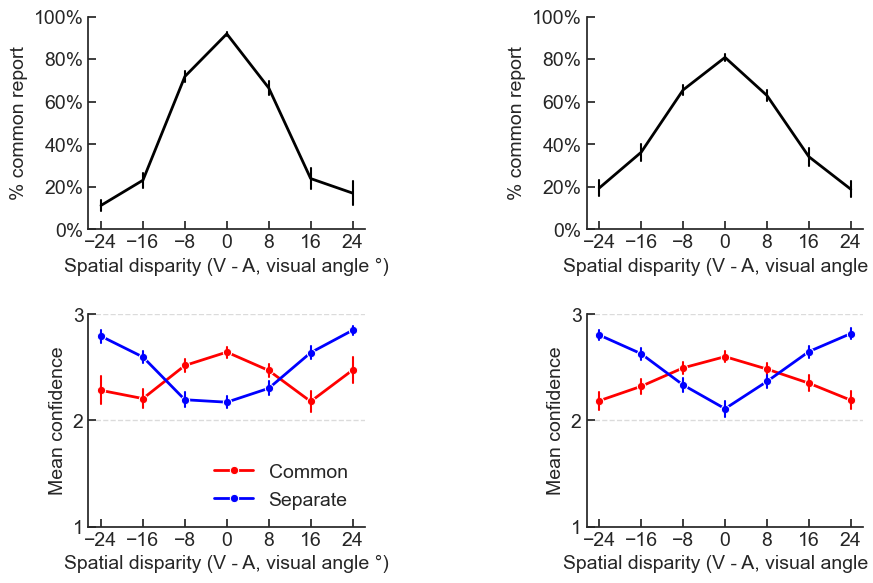

In [8]:


hue_order = ["Common", "Separate"]
color_order = ['red', 'blue']


fig, _axs = plt.subplots(figsize=(10, 6), nrows = 2, ncols = 2, gridspec_kw={'hspace': 0.4, 'wspace': 0.8})
#height_ratios = [4, 3], width_ratios = [3.8, 3, 3, 2], hspace=0.4, wspace=0.4
axs = _axs.flatten()

plot_avg_conf(meanBehConfBySub, axs[2])
plot_avg_conf(meanPredConfBySub, axs[3], None)

plotCNT_common(cntBehComBySub, axs[0])
plotCNT_common(cntPredComBySub, axs[1])

# plotCNT(cntConfCombySub, axs[4], hue_order[0], color_order[0])
# plotCNT(cntConfCombySub, axs[6], hue_order[1], color_order[1])
# plotCNT(cntConfPredCom, axs[5], hue_order[0], color_order[0])
# plotCNT(cntConfPredCom, axs[7], hue_order[1], color_order[1])

for ax in axs:
    clean_axs(ax, fontsize)
    ax.set_xticks([-24, -16, -8, 0, 8, 16, 24])

#add x and y for the two smaller plots
# fig.text(0.045, 0.2, "# cases / # total trials", fontsize=fontsize, va='center', rotation='vertical')
# fig.text(0.55, 0.2, "# cases / # total trials", fontsize=fontsize, va='center', rotation='vertical')

for ax in axs[6:]:
    ax.yaxis.set_major_locator(MultipleLocator(0.025))
    ax.set_xlabel("Spatial disparity (V - A, visual angle \u00B0)", fontsize=fontsize)

style_legend = [
        mlines.Line2D([0], [0], color='black', linestyle='-', label='High'),
        mlines.Line2D([0], [0], color='black', linestyle='--', label='Medium'),
        mlines.Line2D([0], [0], color='black', linestyle=':', label='Low')
    ]
#axs[4].legend(handles=style_legend, title="Confidence:", loc = 'upper left', title_fontsize=fontsize, fontsize = fontsize, bbox_to_anchor=(0.62, 1.4), frameon=False)
plt.subplots_adjust(right = 0.9, top = 0.95, bottom = 0.1)
#plt.savefig(os.path.join(work_path, "plot4paper", "Figure3-AVphase.png"), dpi=300)  # Adjust dpi for print quality
plt.show()

In [9]:
#########Model Prediction
df_sim_allsub_xdiff = processPredDat(74, sub_id_lst)

# Data for fig B  - average confidence by sub
meanPredConfBySub_xdiff = df_sim_allsub_xdiff.groupby(['sub_id', 'delta_VA','ComSourLbl'])['R_conf'].agg(['mean', 'count']).reset_index()
meanPredConfBySub_xdiff.columns = ['sub_id', 'delta_VA','ComSourLbl', 'avgConfLvl', 'count']



C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


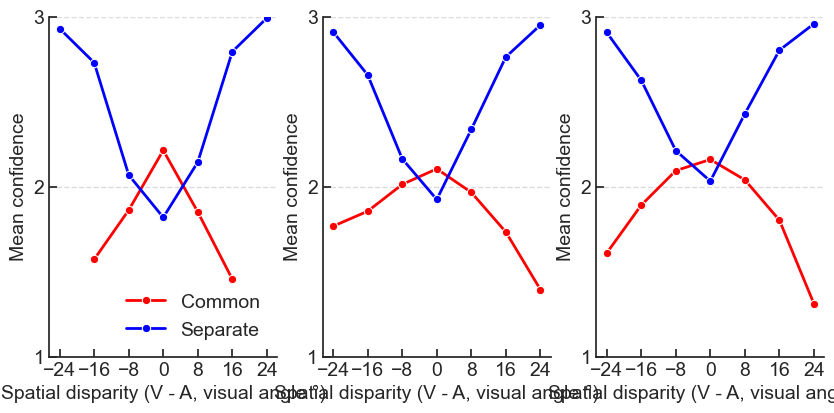

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


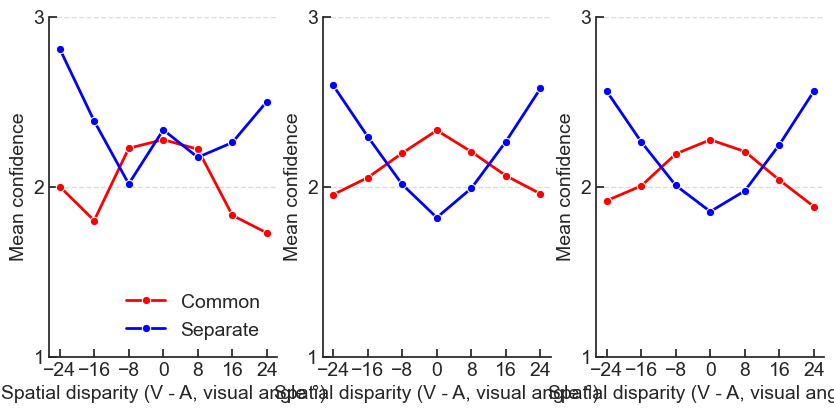

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


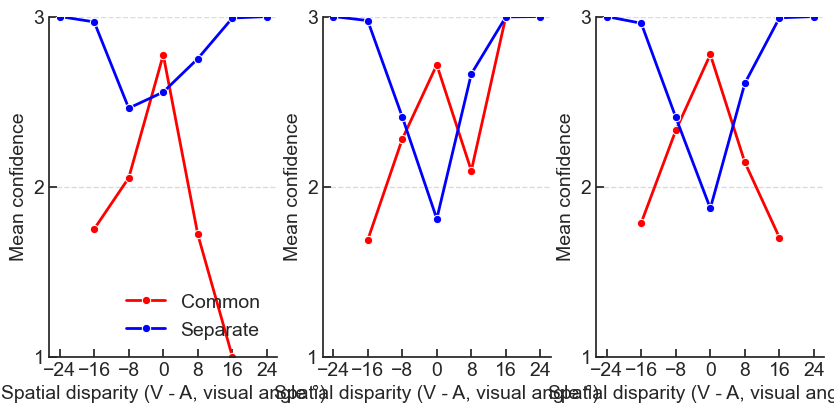

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


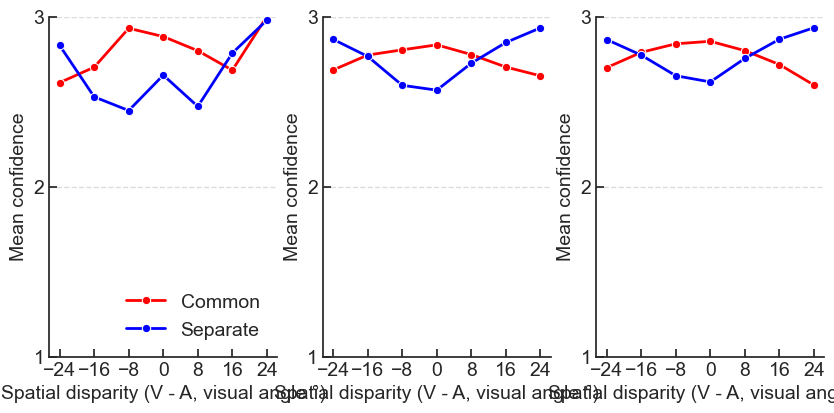

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


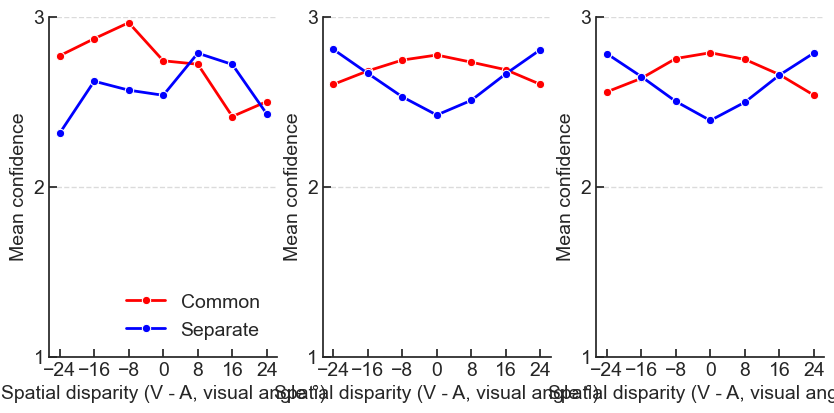

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


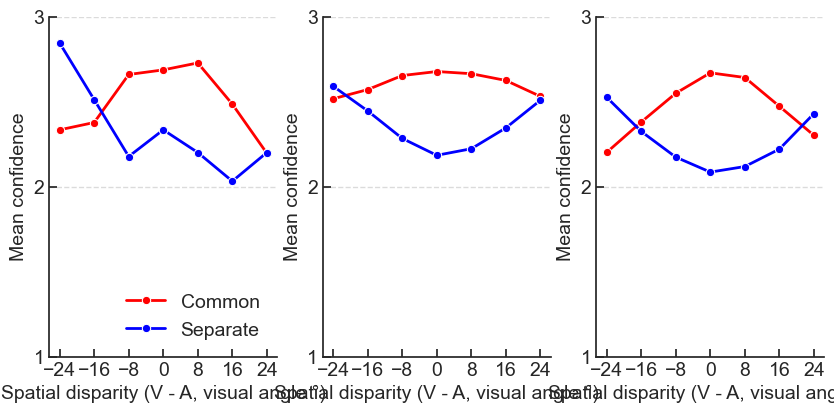

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


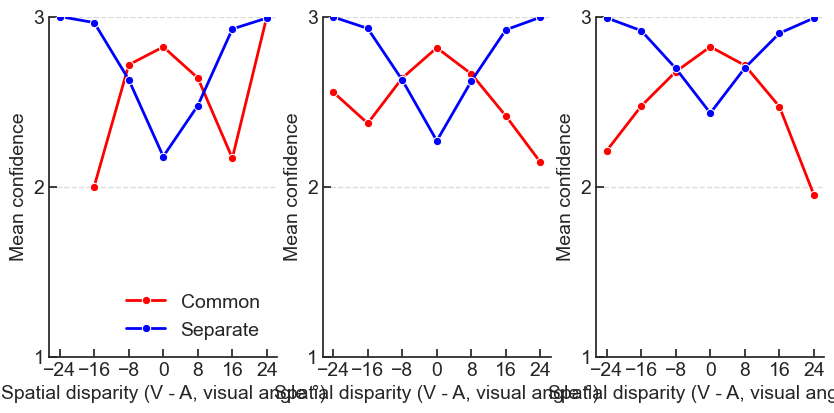

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


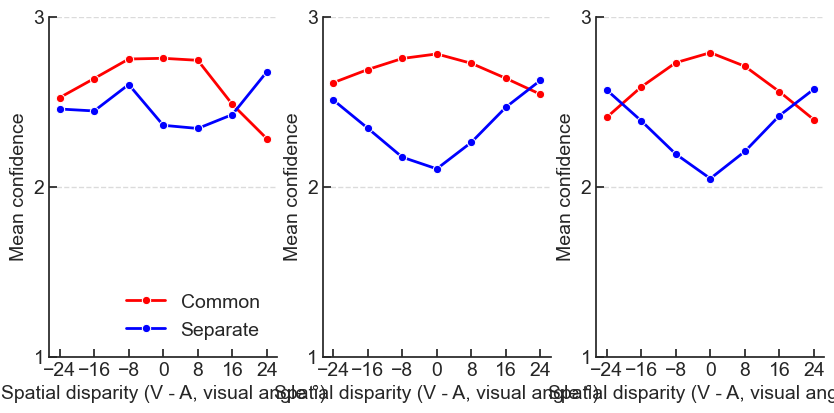

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


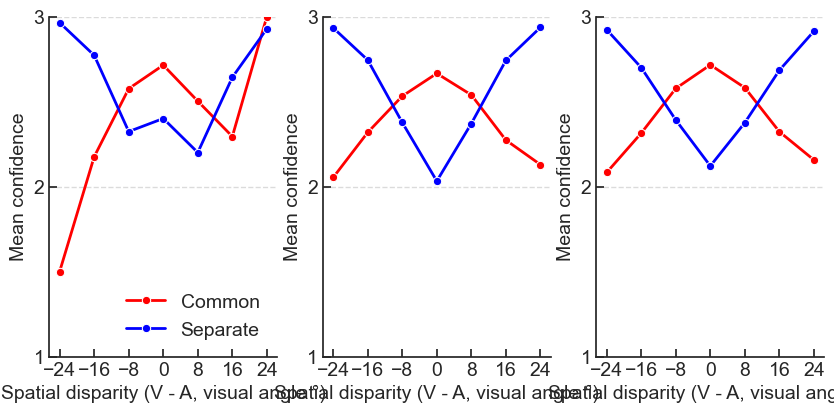

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


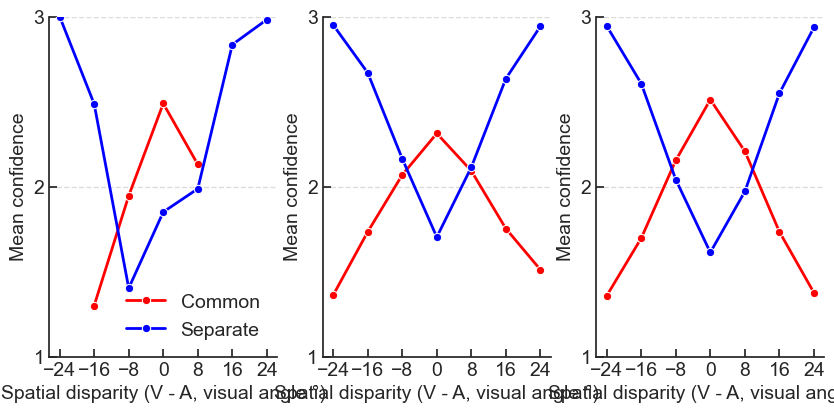

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


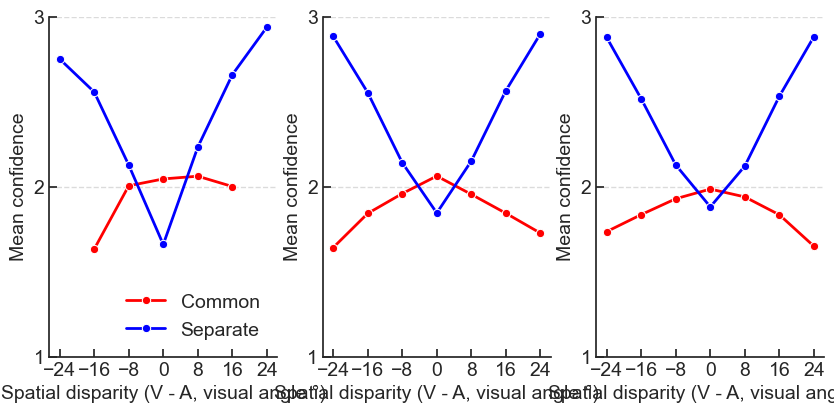

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


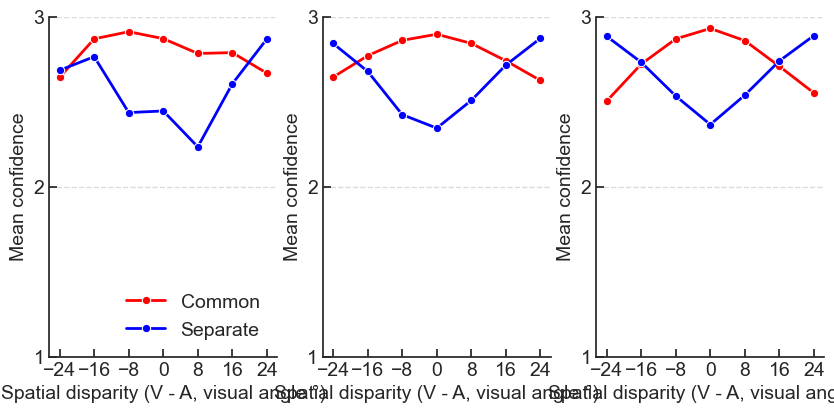

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


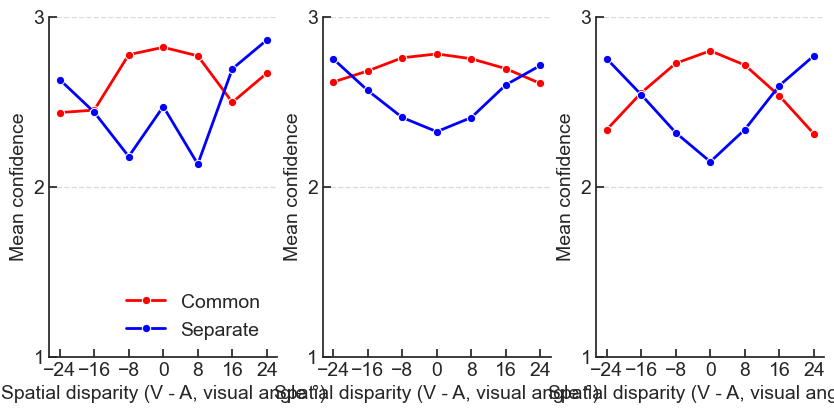

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


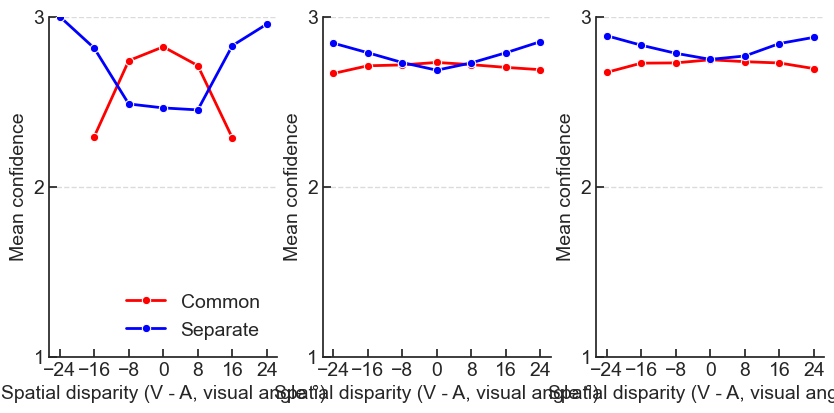

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


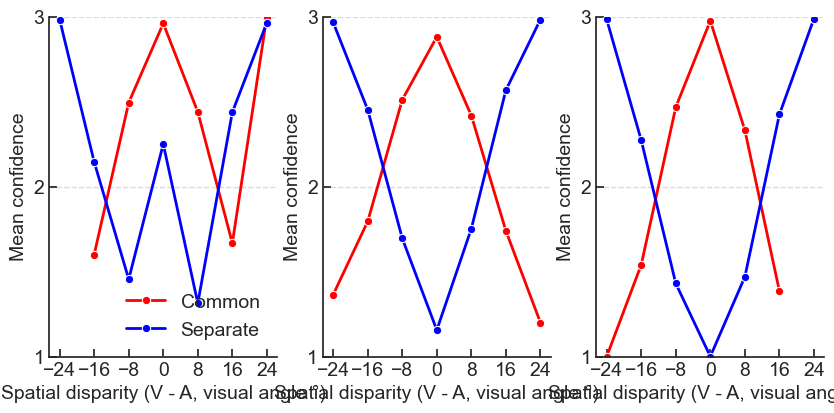

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


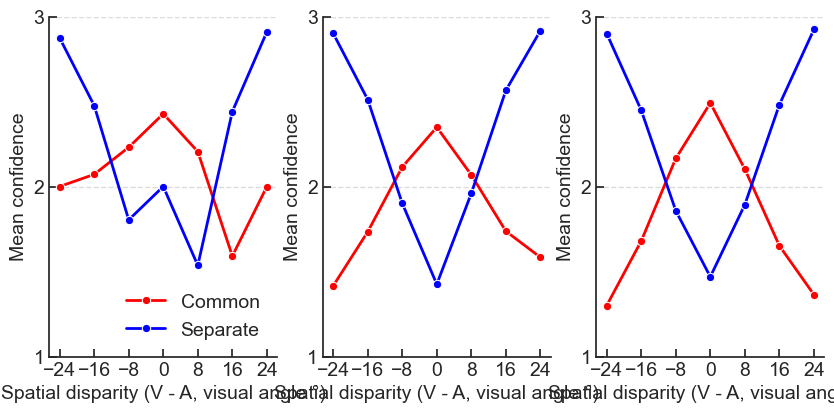

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


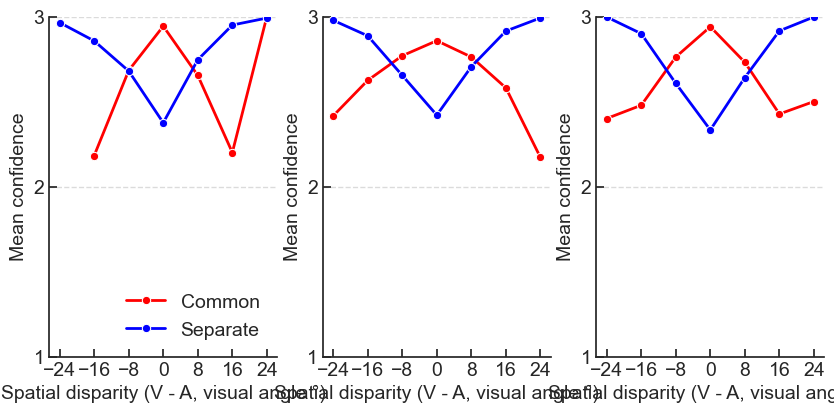

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


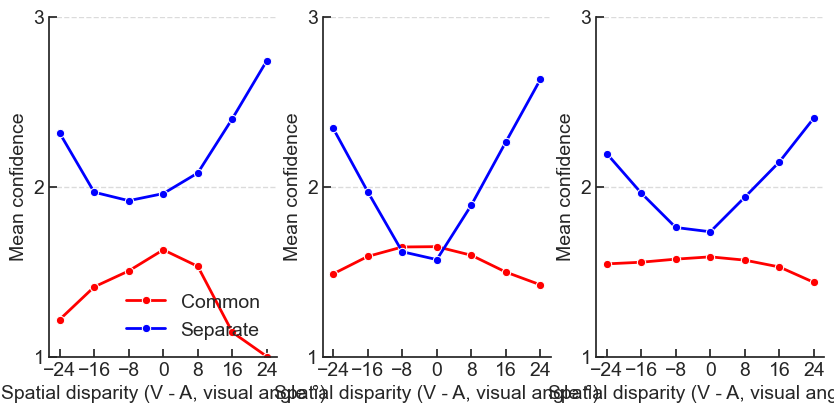

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


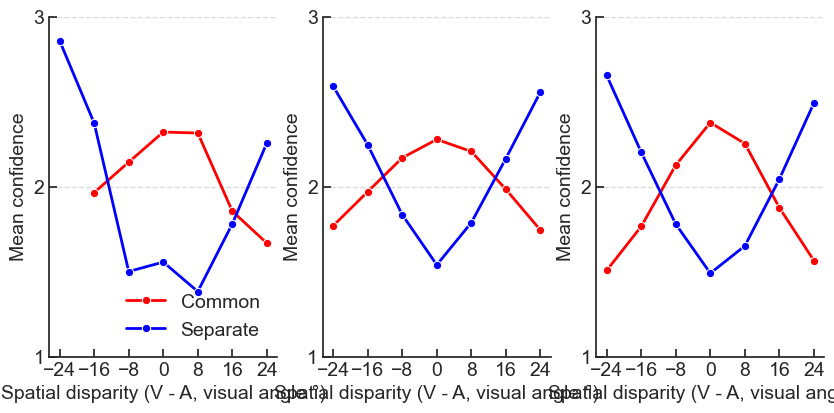

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


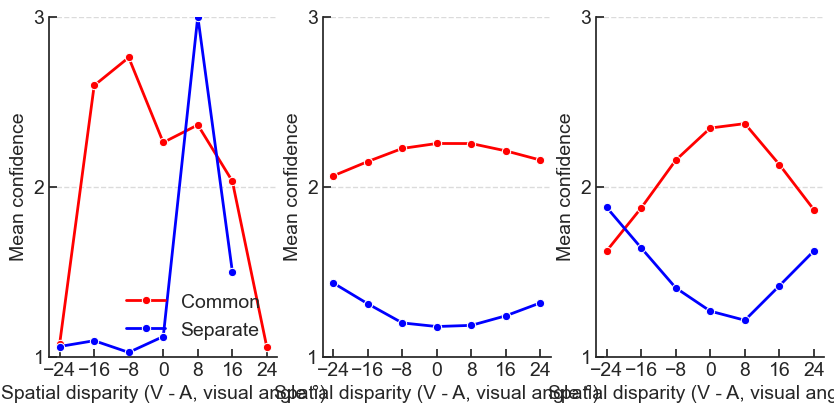

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


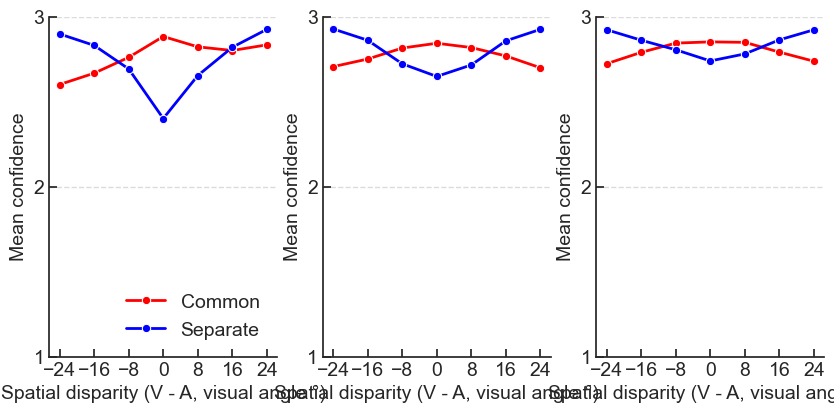

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


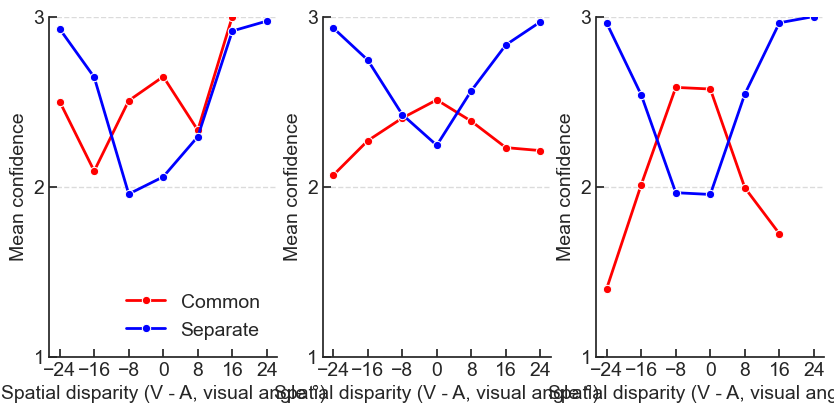

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


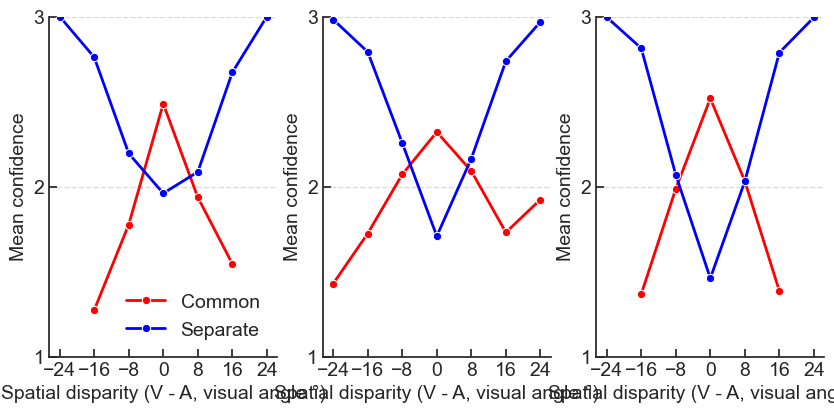

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


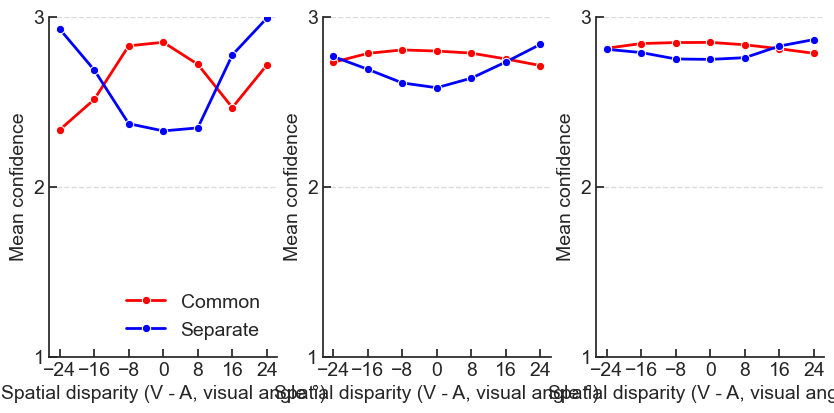

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


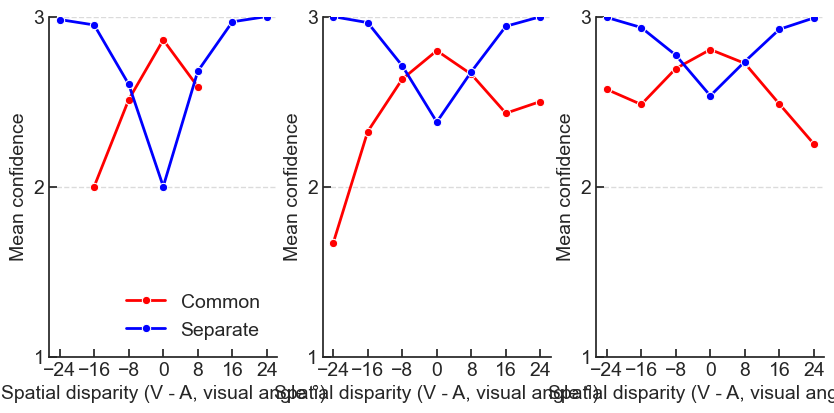

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


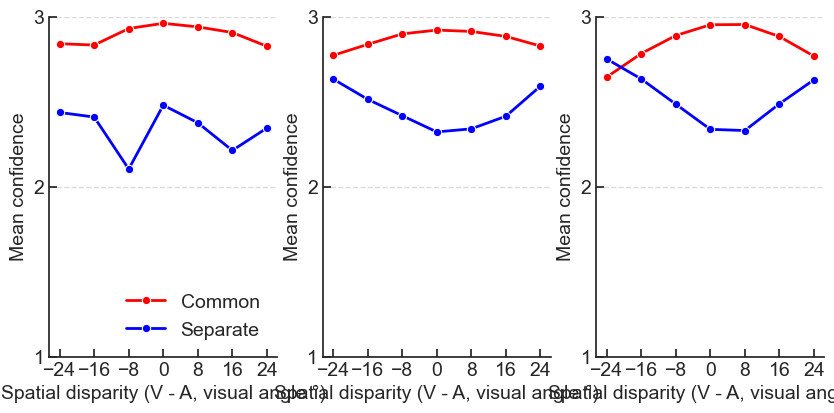

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


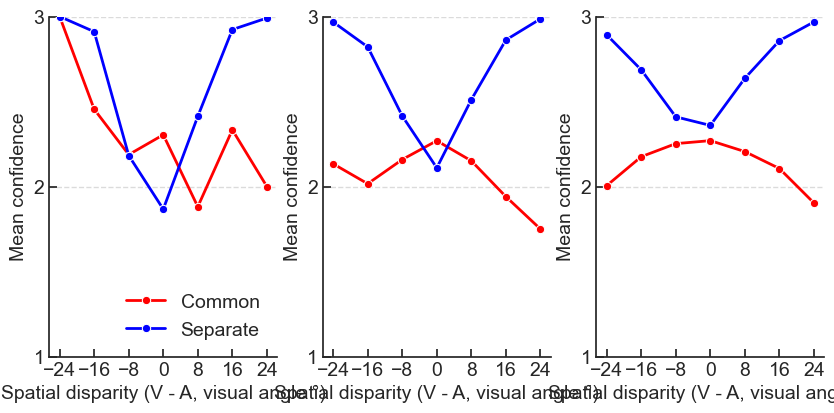

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


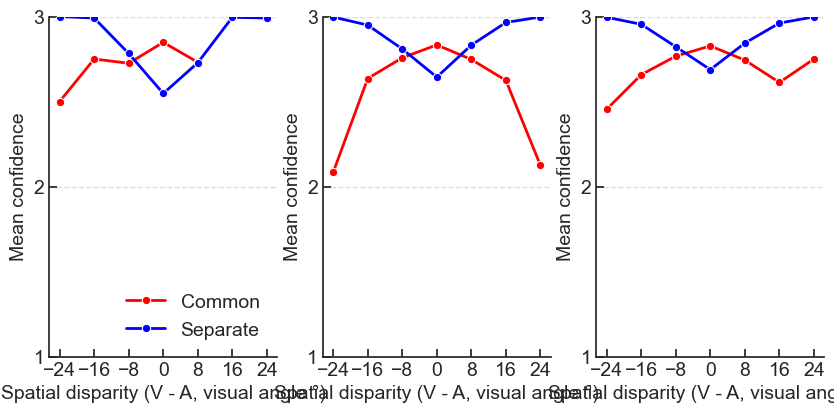

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


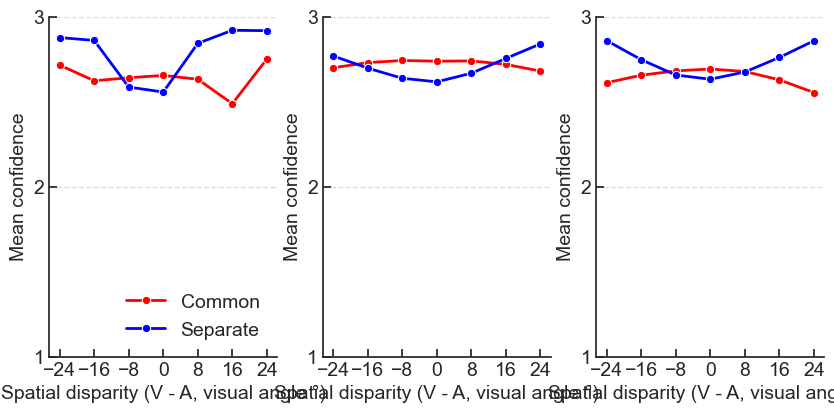

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


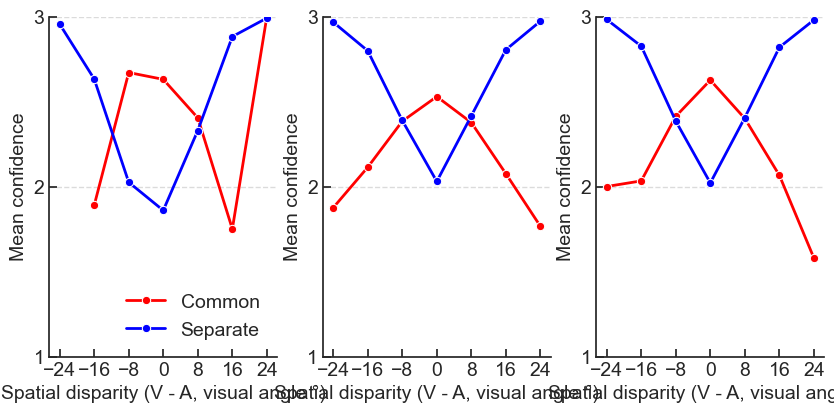

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


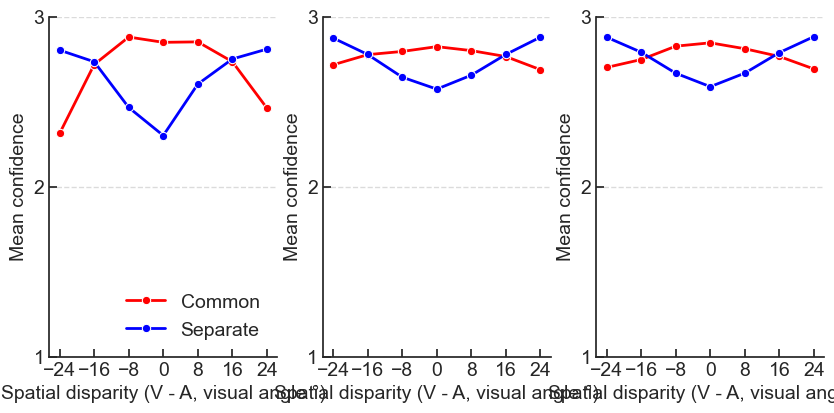

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


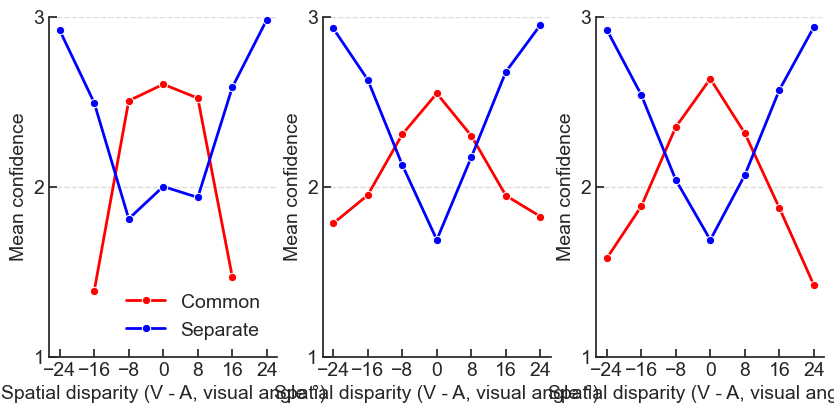

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


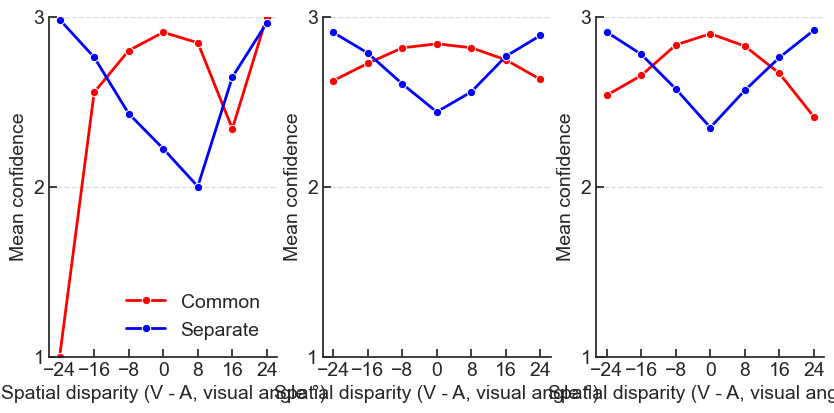

C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_17236\895670575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='', loc = 'lower right', fontsize = fontsize, frameon=False)


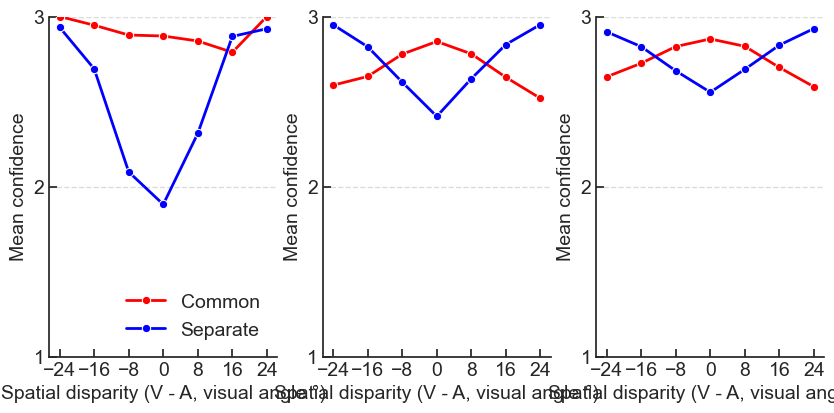

In [10]:
# for each subject
hue_order = ["Common", "Separate"]
color_order = ['red', 'blue']

for sub_id in sub_id_lst:
    fig, axs = plt.subplots(figsize=(10, 4), nrows = 1, ncols = 3, gridspec_kw={'wspace': 0.2})
    #height_ratios = [4, 3], width_ratios = [3.8, 3, 3, 2], hspace=0.4, wspace=0.4
    #axs = _axs.flatten()

    plot_avg_conf(meanBehConfBySub[meanBehConfBySub.sub_id == sub_id], axs[0])
    plot_avg_conf(meanPredConfBySub[meanPredConfBySub.sub_id == sub_id], axs[1], None)
    plot_avg_conf(meanPredConfBySub_xdiff[meanPredConfBySub_xdiff.sub_id == sub_id], axs[2], None)


    for ax in axs: 
        clean_axs(ax, fontsize)
        ax.set_xticks([-24, -16, -8, 0, 8, 16, 24])

    for ax in axs[6:]:
        ax.yaxis.set_major_locator(MultipleLocator(0.025))
        ax.set_xlabel("Spatial disparity (V - A, visual angle \u00B0)", fontsize=fontsize)

    style_legend = [
            mlines.Line2D([0], [0], color='black', linestyle='-', label='High'),
            mlines.Line2D([0], [0], color='black', linestyle='--', label='Medium'),
            mlines.Line2D([0], [0], color='black', linestyle=':', label='Low')
        ]
    #axs[4].legend(handles=style_legend, title="Confidence:", loc = 'upper left', title_fontsize=fontsize, fontsize = fontsize, bbox_to_anchor=(0.62, 1.4), frameon=False)
    plt.subplots_adjust(right = 0.9, top = 0.95, bottom = 0.1)
    plt.savefig(os.path.join(work_path, "plot4paper",'sub_level', f"Figure3-AVphase_sub_{sub_id}.png"), dpi=300)  # Adjust dpi for print quality
    plt.show()
